# Notebook 08 — RA + MURA Combined Training

**Project:** P63 – Multimodal Deep Learning for Autoimmune Disease Diagnosis  
**Phase:** Binary RA vs Control Classification (Balanced Dataset)

---

## Purpose

Train a ResNet-18 binary classifier on a **fully balanced** dataset:

- **Class 1 (RA):** 1120 RA images from RAM-H1200-v1 dataset (`isRA==1` only)
- **Class 0 (Control):** 1120 MURA-negative normal hand X-rays

**Total:** 2240 images (Train=1438, Val=272, Test=530)

---

## Important Notes

- The existing RA manifests contain some RAM-H1200 `isRA=0` rows (74 train / 4 val / 2 test). These are **NOT used** in this experiment.
- MURA-negative images are used as **radiographically normal control samples** — **NOT** clinically confirmed absence of RA.
- This notebook does **NOT** modify any original dataset, manifest, or existing RA checkpoint.
- New combined model checkpoint saved to `models/ra_mura_combined/`.

---
## Section 1 — Project Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT:', PROJECT_ROOT)

PROJECT_ROOT: C:\Users\varsh\OneDrive\Documents\FYP


---
## Section 2 — Imports and Configuration

In [2]:
import os
import random
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

sns.set_theme(style='whitegrid', palette='muted')
Image.MAX_IMAGE_PIXELS = None

# ── Paths ─────────────────────────────────────────────────────────────────────
REPORTS_DIR       = PROJECT_ROOT / 'outputs' / 'reports'
PLOTS_DIR         = PROJECT_ROOT / 'outputs' / 'plots'
MODEL_SAVE_DIR    = PROJECT_ROOT / 'models' / 'ra_mura_combined'
COMBINED_MAN_DIR  = PROJECT_ROOT / 'outputs' / 'manifests' / 'ra_mura_combined'

# Existing manifests
RA_TRAIN_CSV   = REPORTS_DIR / 'train_manifest.csv'
RA_VAL_CSV     = REPORTS_DIR / 'val_manifest.csv'
RA_TEST_CSV    = REPORTS_DIR / 'test_manifest.csv'
MURA_CTRL_CSV  = REPORTS_DIR / 'mura_controls_manifest.csv'
NORM_STATS_CSV = REPORTS_DIR / 'normalisation_stats.csv'

# Create output directories
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
COMBINED_MAN_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Configuration ─────────────────────────────────────────────────────────────
RANDOM_SEED  = 42
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 16
NUM_EPOCHS   = 20
LR           = 0.0001
WEIGHT_DECAY = 0.0001
PATIENCE     = 7
DROPOUT      = 0.5

# Expected counts (for assertion)
EXPECTED_COUNTS = {
    'train': {'ra': 719, 'mura': 719, 'total': 1438},
    'val'  : {'ra': 136, 'mura': 136, 'total': 272},
    'test' : {'ra': 265, 'mura': 265, 'total': 530},
}

# Reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Running on CPU (training will be slower)')

Device: cpu
Running on CPU (training will be slower)


---
## Section 3 — Load Normalisation Statistics

In [3]:
norm_stats = pd.read_csv(NORM_STATS_CSV)
MEAN_VALS  = norm_stats['mean'].tolist()
STD_VALS   = norm_stats['std'].tolist()

print('RA dataset normalisation statistics:')
print(norm_stats.to_string(index=False))
print()
print(f'MEAN: {MEAN_VALS}')
print(f'STD : {STD_VALS}')

RA dataset normalisation statistics:
channel     mean      std
      R 0.250363 0.253111
      G 0.250363 0.253111
      B 0.250363 0.253111

MEAN: [0.2503633202338705, 0.2503633202338705, 0.2503633202338705]
STD : [0.2531105167199891, 0.2531105167199891, 0.2531105167199891]


---
## Section 4 — Load and Filter RA Manifests (isRA==1 ONLY)

In [4]:
print('Loading RA manifests and filtering to isRA==1 only...')
print()

ra_train_full = pd.read_csv(RA_TRAIN_CSV)
ra_val_full   = pd.read_csv(RA_VAL_CSV)
ra_test_full  = pd.read_csv(RA_TEST_CSV)

# Filter to isRA==1 only
ra_train = ra_train_full[ra_train_full['isRA'] == 1].copy()
ra_val   = ra_val_full  [ra_val_full  ['isRA'] == 1].copy()
ra_test  = ra_test_full [ra_test_full ['isRA'] == 1].copy()

print('=== RA MANIFEST FILTERING (isRA==1 only) ===')
print(f'{"Split":<8} {"Original":>10} {"isRA==1":>10} {"isRA==0":>10} {"After_Filter":>13}')
print('-' * 55)
for name, df_full, df_filt in [
    ('train', ra_train_full, ra_train),
    ('val',   ra_val_full,   ra_val),
    ('test',  ra_test_full,  ra_test),
]:
    n_orig  = len(df_full)
    n_ra1   = int((df_full['isRA']==1).sum())
    n_ra0   = int((df_full['isRA']==0).sum())
    n_filt  = len(df_filt)
    print(f'{name:<8} {n_orig:>10} {n_ra1:>10} {n_ra0:>10} {n_filt:>13}')

print()
print('IMPORTANT: The isRA==0 rows (80 total) from RAM-H1200 are NOT used.')

Loading RA manifests and filtering to isRA==1 only...

=== RA MANIFEST FILTERING (isRA==1 only) ===
Split      Original    isRA==1    isRA==0  After_Filter
-------------------------------------------------------
train           793        719         74           719
val             140        136          4           136
test            267        265          2           265

IMPORTANT: The isRA==0 rows (80 total) from RAM-H1200 are NOT used.


---
## Section 5 — Load MURA Control Manifest

In [5]:
print('Loading MURA control manifest...')
mura_ctrl = pd.read_csv(MURA_CTRL_CSV)

# Filter by split
mura_train = mura_ctrl[mura_ctrl['split'] == 'train'].copy()
mura_val   = mura_ctrl[mura_ctrl['split'] == 'val'].copy()
mura_test  = mura_ctrl[mura_ctrl['split'] == 'test'].copy()

print()
print('=== MURA CONTROL MANIFEST ===')
print(f'{"Split":<8} {"Images":>10}')
print('-' * 22)
for name, df in [('train', mura_train), ('val', mura_val), ('test', mura_test)]:
    print(f'{name:<8} {len(df):>10}')
print('-' * 22)
print(f'{"TOTAL":<8} {len(mura_ctrl):>10}')

Loading MURA control manifest...

=== MURA CONTROL MANIFEST ===
Split        Images
----------------------
train           719
val             136
test            265
----------------------
TOTAL          1120


---
## Section 6 — Create Combined Manifests

In [6]:
def create_combined_manifest(ra_df, mura_df, split_name):
    # RA rows
    ra_combined = pd.DataFrame({
        'filename'     : ra_df['filename'].values,
        'full_path'    : ra_df['full_path'].values,
        'split'        : split_name,
        'label'        : 1,
        'source'       : 'RAM-H1200_RA',
        'patient_id'   : ra_df['Normalized PatientID'].values,
        'original_path': ra_df['full_path'].values,
    })
    
    # MURA rows
    mura_combined = pd.DataFrame({
        'filename'     : mura_df['filename'].values,
        'full_path'    : [str(PROJECT_ROOT / p) for p in mura_df['image_path'].values],
        'split'        : split_name,
        'label'        : 0,
        'source'       : 'MURA_negative_control',
        'patient_id'   : mura_df['patient_id'].values,
        'original_path': mura_df['original_mura_path'].values,
    })
    
    # Concatenate and shuffle
    combined = pd.concat([ra_combined, mura_combined], ignore_index=True)
    combined = combined.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    return combined


print('Creating combined manifests...')

combined_train = create_combined_manifest(ra_train, mura_train, 'train')
combined_val   = create_combined_manifest(ra_val,   mura_val,   'val')
combined_test  = create_combined_manifest(ra_test,  mura_test,  'test')

# Save to disk
combined_train.to_csv(COMBINED_MAN_DIR / 'train_combined_manifest.csv', index=False)
combined_val.to_csv  (COMBINED_MAN_DIR / 'val_combined_manifest.csv',   index=False)
combined_test.to_csv (COMBINED_MAN_DIR / 'test_combined_manifest.csv',  index=False)

print(f'Combined manifests saved to: {COMBINED_MAN_DIR}')
print(f'  train: {len(combined_train)} rows')
print(f'  val  : {len(combined_val)} rows')
print(f'  test : {len(combined_test)} rows')

Creating combined manifests...
Combined manifests saved to: C:\Users\varsh\OneDrive\Documents\FYP\outputs\manifests\ra_mura_combined
  train: 1438 rows
  val  : 272 rows
  test : 530 rows


---
## Section 7 — Verify Combined Manifest Counts

In [7]:
print('=' * 70)
print('COMBINED MANIFEST VERIFICATION')
print('=' * 70)
print()

all_ok = True
for split_name, df in [('train', combined_train), ('val', combined_val), ('test', combined_test)]:
    exp = EXPECTED_COUNTS[split_name]
    n_ra   = int((df['label'] == 1).sum())
    n_mura = int((df['label'] == 0).sum())
    n_tot  = len(df)
    
    status = 'PASS' if (n_ra == exp['ra'] and n_mura == exp['mura'] and n_tot == exp['total']) else 'FAIL'
    if status == 'FAIL': all_ok = False
    
    print(f'{split_name.upper():<8}: RA={n_ra:4d} (exp={exp["ra"]:4d})  MURA={n_mura:4d} (exp={exp["mura"]:4d})  Total={n_tot:4d} [{status}]')

print()
if all_ok:
    print('✓ All count checks PASSED.')
else:
    raise AssertionError('Count mismatch!')

COMBINED MANIFEST VERIFICATION

TRAIN   : RA= 719 (exp= 719)  MURA= 719 (exp= 719)  Total=1438 [PASS]
VAL     : RA= 136 (exp= 136)  MURA= 136 (exp= 136)  Total= 272 [PASS]
TEST    : RA= 265 (exp= 265)  MURA= 265 (exp= 265)  Total= 530 [PASS]

✓ All count checks PASSED.


---
## Section 8 — Verify Label Correctness

In [8]:
print('=' * 70)
print('LABEL CORRECTNESS VERIFICATION')
print('=' * 70)

combined_all = pd.concat([combined_train, combined_val, combined_test], ignore_index=True)

ra_rows = combined_all[combined_all['source'] == 'RAM-H1200_RA']
assert (ra_rows['label'] == 1).all(), 'RA label error'
print(f'1. All RA rows have label=1: True ({len(ra_rows)} rows)')

mura_rows = combined_all[combined_all['source'] == 'MURA_negative_control']
assert (mura_rows['label'] == 0).all(), 'MURA label error'
print(f'2. All MURA rows have label=0: True ({len(mura_rows)} rows)')

assert mura_rows['original_path'].str.lower().str.contains('negative').all()
print(f'3. All MURA paths contain "negative": True')

print()
print('✓ All label correctness checks PASSED.')

LABEL CORRECTNESS VERIFICATION
1. All RA rows have label=1: True (1120 rows)
2. All MURA rows have label=0: True (1120 rows)
3. All MURA paths contain "negative": True

✓ All label correctness checks PASSED.


---
## Section 9 — File Existence and Duplicate Checks

In [9]:
print('=' * 70)
print('FILE EXISTENCE AND DUPLICATE CHECK')
print('=' * 70)

n_missing = 0
for _, row in combined_all.iterrows():
    if not Path(row['full_path']).exists():
        n_missing += 1
        if n_missing <= 5:
            print(f'  MISSING: {row["full_path"][-60:]}')

print(f'1. Missing files: {n_missing} (MUST BE 0)')
if n_missing > 0:
    raise AssertionError(f'{n_missing} files missing')

# Duplicate checks
dup_paths = len(combined_all) - combined_all['full_path'].nunique()
dup_orig  = len(combined_all) - combined_all['original_path'].nunique()
print(f'2. Duplicate full_path: {dup_paths} (MUST BE 0)')
print(f'3. Duplicate original_path: {dup_orig} (MUST BE 0)')

if dup_paths > 0 or dup_orig > 0:
    raise AssertionError('Duplicate images detected')

print()
print('✓ All file and duplicate checks PASSED.')

FILE EXISTENCE AND DUPLICATE CHECK
1. Missing files: 0 (MUST BE 0)
2. Duplicate full_path: 0 (MUST BE 0)
3. Duplicate original_path: 0 (MUST BE 0)

✓ All file and duplicate checks PASSED.


---
## Section 10 — Patient-Level Split Verification

In [10]:
print('=' * 70)
print('PATIENT-LEVEL SPLIT VERIFICATION')
print('=' * 70)

# MURA patient leakage
mura_train_pts = set(combined_train[combined_train['source']=='MURA_negative_control']['patient_id'])
mura_val_pts   = set(combined_val[combined_val['source']=='MURA_negative_control']['patient_id'])
mura_test_pts  = set(combined_test[combined_test['source']=='MURA_negative_control']['patient_id'])

print('MURA control patients:')
print(f'  Train: {len(mura_train_pts)} unique patients')
print(f'  Val  : {len(mura_val_pts)} unique patients')
print(f'  Test : {len(mura_test_pts)} unique patients')
print(f'  Val ∩ Test  : {len(mura_val_pts & mura_test_pts)} (MUST BE 0)')
print(f'  Val ∩ Train : {len(mura_val_pts & mura_train_pts)} (MUST BE 0)')
print(f'  Test ∩ Train: {len(mura_test_pts & mura_train_pts)} (MUST BE 0)')

if (mura_val_pts & mura_test_pts) or (mura_val_pts & mura_train_pts) or (mura_test_pts & mura_train_pts):
    raise AssertionError('MURA patient leakage detected!')

print()
print('✓ Zero MURA patient overlap.')

PATIENT-LEVEL SPLIT VERIFICATION
MURA control patients:
  Train: 254 unique patients
  Val  : 49 unique patients
  Test : 97 unique patients
  Val ∩ Test  : 0 (MUST BE 0)
  Val ∩ Train : 0 (MUST BE 0)
  Test ∩ Train: 0 (MUST BE 0)

✓ Zero MURA patient overlap.


---
## Section 11 — Sample Visualisation

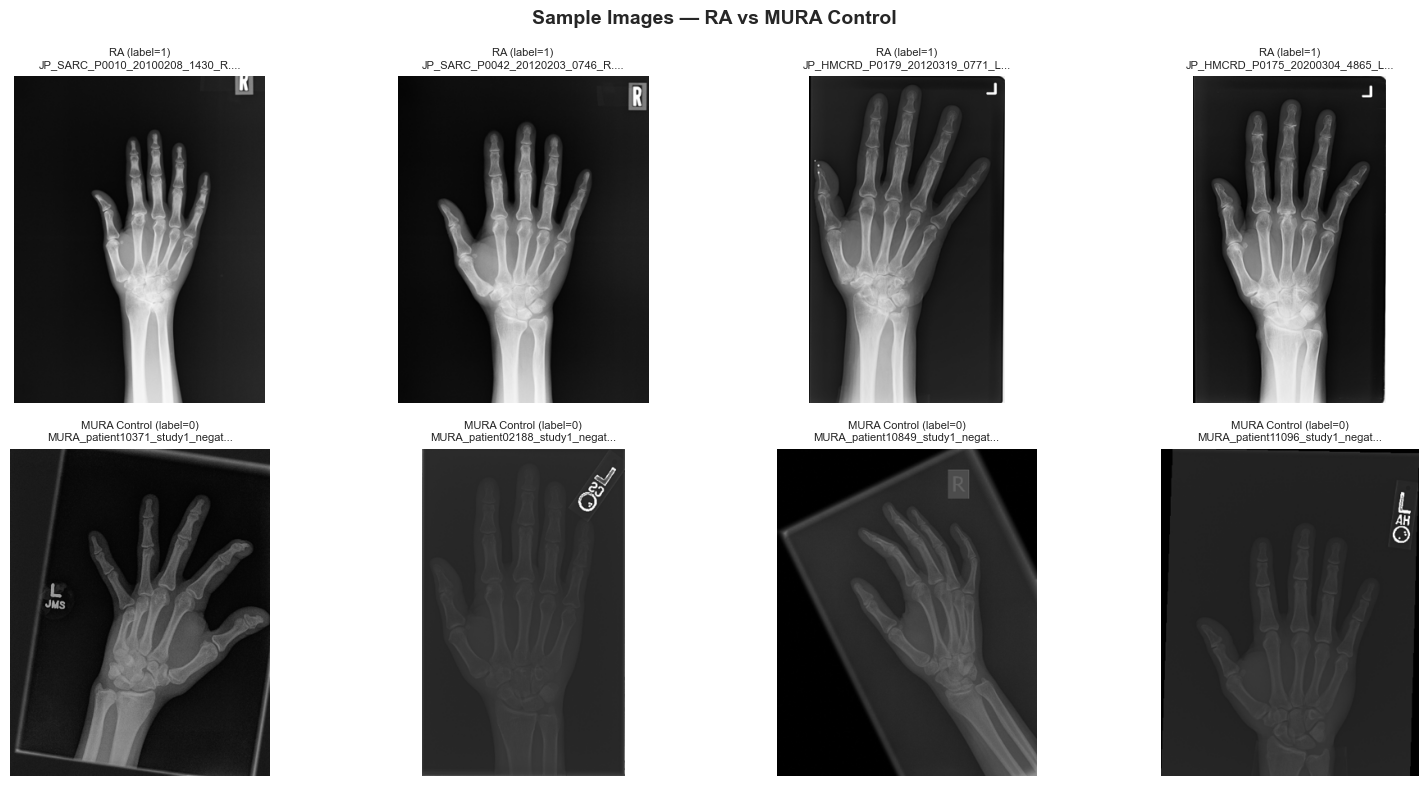

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

fig.suptitle(
    'Sample Images — RA vs MURA Control',
    fontsize=14,
    fontweight='bold'
)

# -----------------------------
# RA samples
# -----------------------------
ra_samples = combined_train[
    combined_train['label'] == 1
].sample(4, random_state=42)

for i, (_, row) in enumerate(ra_samples.iterrows()):

    with Image.open(row['full_path']) as img:
        thumb = img.convert('RGB')
        thumb.thumbnail((400, 400))

    axes[0][i].imshow(thumb)
    axes[0][i].set_title(
        f'RA (label=1)\n{row["filename"][:30]}...',
        fontsize=8
    )
    axes[0][i].axis('off')


# -----------------------------
# MURA control samples
# -----------------------------
mura_samples = combined_train[
    combined_train['label'] == 0
].sample(4, random_state=42)

for i, (_, row) in enumerate(mura_samples.iterrows()):

    with Image.open(row['full_path']) as img:
        thumb = img.convert('RGB')
        thumb.thumbnail((400, 400))

    axes[1][i].imshow(thumb)
    axes[1][i].set_title(
        f'MURA Control (label=0)\n{row["filename"][:30]}...',
        fontsize=8
    )
    axes[1][i].axis('off')


plt.tight_layout()

plt.savefig(
    PLOTS_DIR / '08_sample_ra_vs_mura.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

---
## Section 12 — Define Transforms

In [13]:
def get_transforms(split, img_size, mean, std):
    normalize = T.Normalize(mean=mean, std=std)
    if split == 'train':
        return T.Compose([
            T.Resize(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            T.ToTensor(),
            normalize,
        ])
    else:
        return T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
            normalize,
        ])

train_transform = get_transforms('train', IMG_SIZE, MEAN_VALS, STD_VALS)
val_transform   = get_transforms('val',   IMG_SIZE, MEAN_VALS, STD_VALS)
test_transform  = get_transforms('test',  IMG_SIZE, MEAN_VALS, STD_VALS)
print('Transforms defined.')

Transforms defined.


---
## Section 13 — Define Dataset and DataLoaders

In [14]:
class CombinedRAMURADataset(Dataset):
    def __init__(self, manifest_df, transform=None):
        self.manifest  = manifest_df.reset_index(drop=True)
        self.transform = transform
    
    def __len__(self):
        return len(self.manifest)
    
    def __getitem__(self, idx):
        row   = self.manifest.iloc[idx]
        path  = Path(row['full_path'])
        label = int(row['label'])
        img   = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = CombinedRAMURADataset(combined_train, transform=train_transform)
val_dataset   = CombinedRAMURADataset(combined_val,   transform=val_transform)
test_dataset  = CombinedRAMURADataset(combined_test,  transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'DataLoaders: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}')

DataLoaders: Train=1438, Val=272, Test=530


---
## Section 14 — Define ResNet-18 Model

In [15]:
class BinaryResNet18(nn.Module):
    def __init__(self, dropout=0.5, pretrained=True):
        super().__init__()
        self.backbone = models.resnet18(pretrained=pretrained)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 1),
        )
    
    def forward(self, x):
        return self.backbone(x)

model = BinaryResNet18(dropout=DROPOUT, pretrained=True).to(device)
print(f'Model created. Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model created. Parameters: 11,439,681


---
## Section 15 — Define Loss, Optimizer, Scheduler

In [17]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

print('Loss, optimizer, scheduler defined.')

Loss, optimizer, scheduler defined.


---
## Section 16 — Training Loop

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

print('Training functions defined.')

Training functions defined.


In [19]:
print('=' * 70)
print('TRAINING RESNET-18')
print('=' * 70)

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  Train: {train_loss:.4f}/{train_acc:.4f}  Val: {val_loss:.4f}/{val_acc:.4f}')
    
    scheduler.step(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_DIR / 'resnet18_best.pth')
        print(f'  → Best model saved')
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'Training complete. Best val_loss: {best_val_loss:.4f}')

TRAINING RESNET-18
Epoch  1/20  Train: 0.1034/0.9645  Val: 0.0006/1.0000
  → Best model saved
Epoch  2/20  Train: 0.0173/0.9965  Val: 0.0001/1.0000
  → Best model saved
Epoch  3/20  Train: 0.0054/0.9993  Val: 0.0283/0.9926
Epoch  4/20  Train: 0.0067/0.9972  Val: 0.0246/0.9926
Epoch  5/20  Train: 0.0022/1.0000  Val: 0.0002/1.0000
Epoch  6/20  Train: 0.0009/1.0000  Val: 0.0001/1.0000
  → Best model saved
Epoch  7/20  Train: 0.0006/1.0000  Val: 0.0000/1.0000
  → Best model saved
Epoch  8/20  Train: 0.0016/1.0000  Val: 0.0002/1.0000
Epoch  9/20  Train: 0.0004/1.0000  Val: 0.0002/1.0000
Epoch 10/20  Train: 0.0001/1.0000  Val: 0.0001/1.0000
Epoch 11/20  Train: 0.0134/0.9965  Val: 0.0001/1.0000
Epoch 12/20  Train: 0.0089/0.9979  Val: 0.0013/1.0000
Epoch 13/20  Train: 0.0007/1.0000  Val: 0.0002/1.0000
Epoch 14/20  Train: 0.0004/1.0000  Val: 0.0001/1.0000
Early stopping at epoch 14
Training complete. Best val_loss: 0.0000


---
## Section 17 — Plot Training History

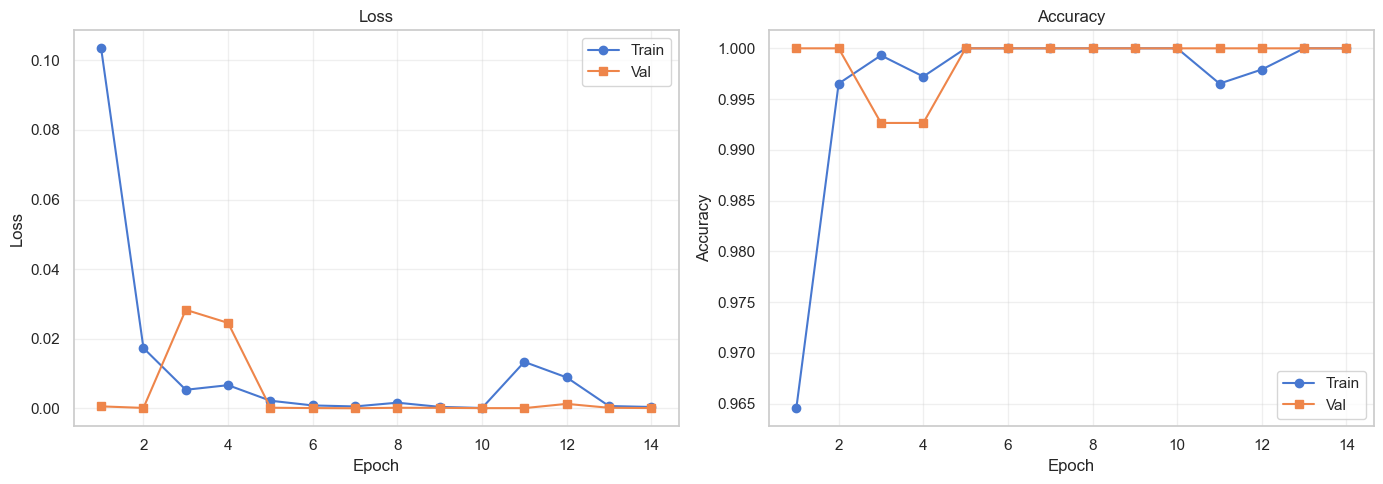

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train')
ax1.plot(epochs_range, history['val_loss'], 's-', label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'o-', label='Train')
ax2.plot(epochs_range, history['val_acc'], 's-', label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '08_training_history.png', dpi=120)
plt.show()

---
## Section 18 — Evaluate on Test Set

In [21]:
print('=' * 70)
print('TEST SET EVALUATION')
print('=' * 70)

model.load_state_dict(torch.load(MODEL_SAVE_DIR / 'resnet18_best.pth', map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.concatenate(all_labels).flatten()
all_preds  = np.concatenate(all_preds).flatten()
all_probs  = np.concatenate(all_probs).flatten()

test_acc  = accuracy_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds, zero_division=0)
test_rec  = recall_score(all_labels, all_preds, zero_division=0)
test_f1   = f1_score(all_labels, all_preds, zero_division=0)
test_auc  = roc_auc_score(all_labels, all_probs)

print(f'Accuracy : {test_acc:.4f}')
print(f'Precision: {test_prec:.4f}')
print(f'Recall   : {test_rec:.4f}')
print(f'F1-Score : {test_f1:.4f}')
print(f'ROC-AUC  : {test_auc:.4f}')
print()
print(classification_report(all_labels, all_preds, target_names=['MURA Control', 'RA'], zero_division=0))

TEST SET EVALUATION
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1-Score : 1.0000
ROC-AUC  : 1.0000

              precision    recall  f1-score   support

MURA Control       1.00      1.00      1.00       265
          RA       1.00      1.00      1.00       265

    accuracy                           1.00       530
   macro avg       1.00      1.00      1.00       530
weighted avg       1.00      1.00      1.00       530



---
## Section 19 — Confusion Matrix

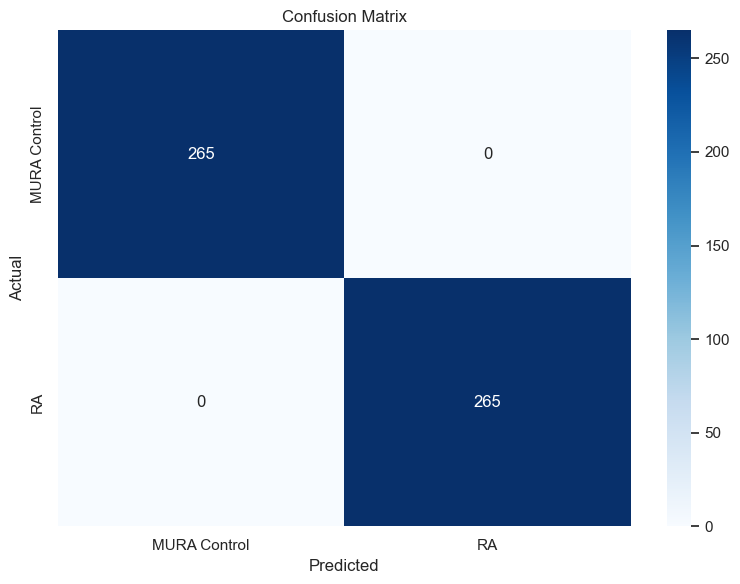

In [22]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['MURA Control', 'RA'],
            yticklabels=['MURA Control', 'RA'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig(PLOTS_DIR / '08_confusion_matrix.png', dpi=120)
plt.show()

---
## Section 20 — ROC Curve

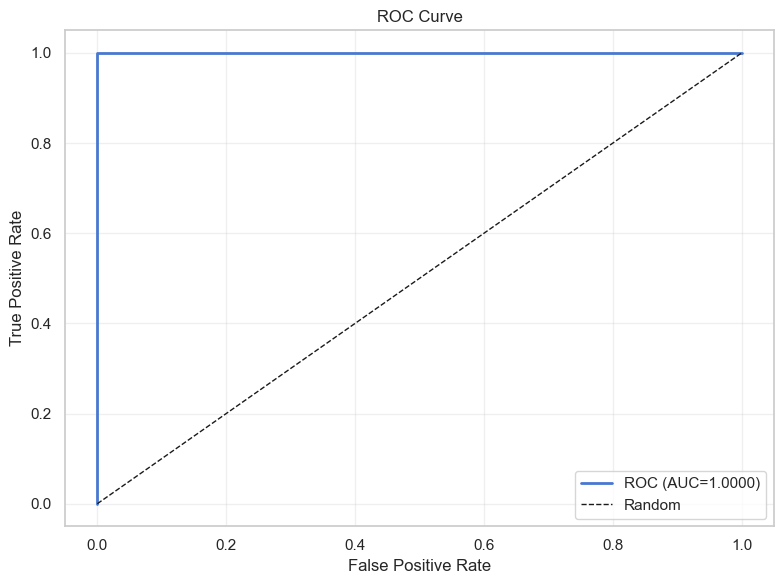

In [23]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, lw=2, label=f'ROC (AUC={test_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / '08_roc_curve.png', dpi=120)
plt.show()

---
## Section 21 — Sample Test Predictions

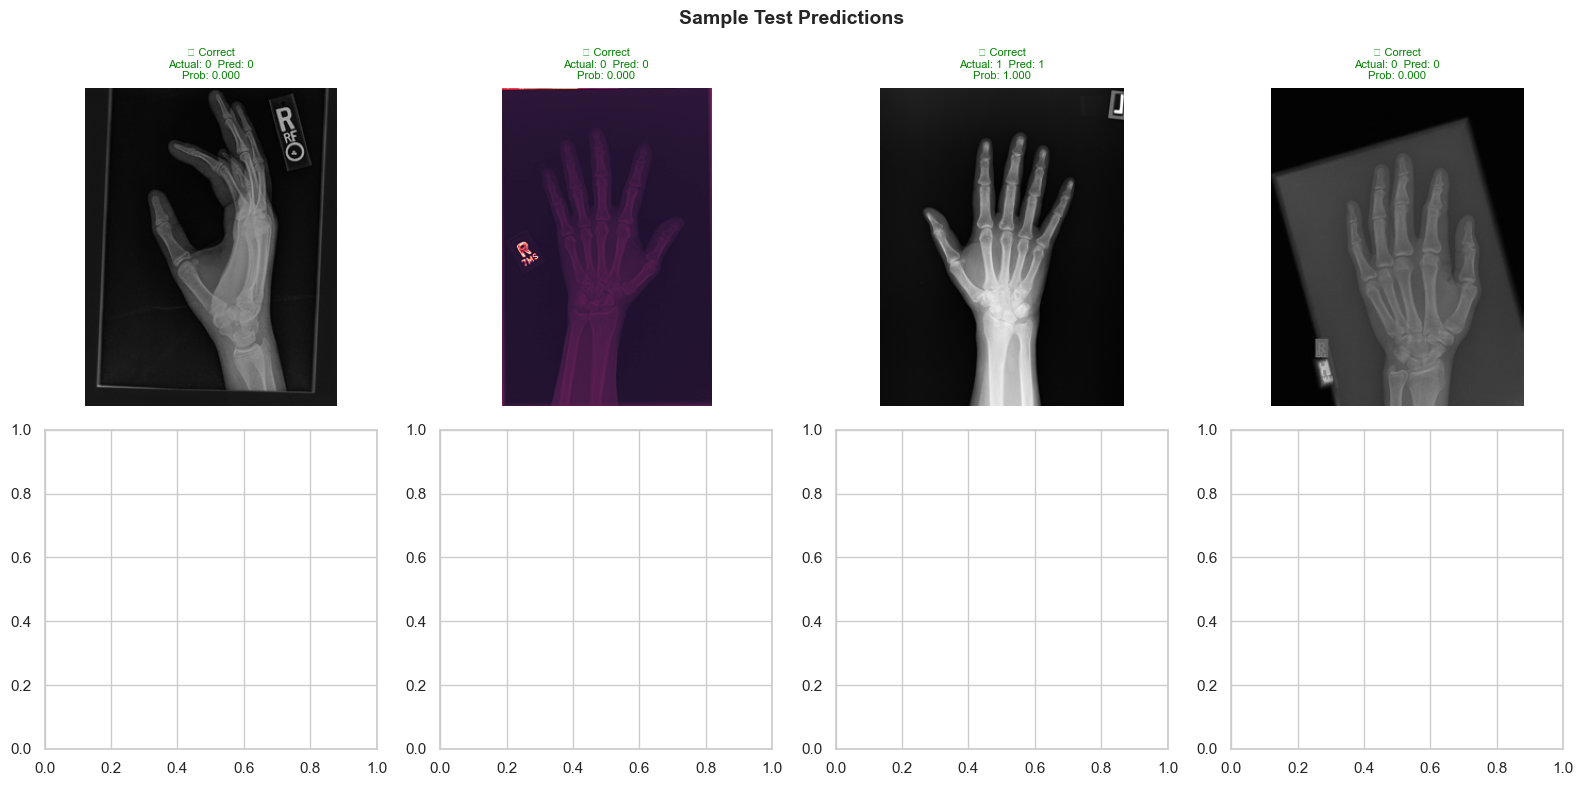

In [25]:
test_results = combined_test.copy()

test_results['pred_label'] = all_preds.astype(int)
test_results['pred_prob'] = all_probs

# Correct predictions
correct_results = test_results[
    test_results['label'] == test_results['pred_label']
]

correct = correct_results.sample(
    min(4, len(correct_results)),
    random_state=42
)

# Incorrect predictions
incorrect_results = test_results[
    test_results['label'] != test_results['pred_label']
]

incorrect = incorrect_results.sample(
    min(4, len(incorrect_results)),
    random_state=42
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

fig.suptitle(
    'Sample Test Predictions',
    fontsize=14,
    fontweight='bold'
)

# --------------------------------
# Correct predictions
# --------------------------------
for i, (_, row) in enumerate(correct.iterrows()):

    with Image.open(row['full_path']) as img:
        if row['source'] == 'RAM-H1200_RA':
            thumb = img.convert('RGB')
        else:
            thumb = img.copy()

        thumb.thumbnail((300, 300))

    axes[0][i].imshow(thumb)

    axes[0][i].set_title(
        f'✓ Correct\n'
        f'Actual: {row["label"]}  Pred: {row["pred_label"]}\n'
        f'Prob: {row["pred_prob"]:.3f}',
        fontsize=8,
        color='green'
    )

    axes[0][i].axis('off')


# --------------------------------
# Incorrect predictions
# --------------------------------
for i, (_, row) in enumerate(incorrect.iterrows()):

    with Image.open(row['full_path']) as img:
        if row['source'] == 'RAM-H1200_RA':
            thumb = img.convert('RGB')
        else:
            thumb = img.copy()

        thumb.thumbnail((300, 300))

    axes[1][i].imshow(thumb)

    axes[1][i].set_title(
        f'✗ Incorrect\n'
        f'Actual: {row["label"]}  Pred: {row["pred_label"]}\n'
        f'Prob: {row["pred_prob"]:.3f}',
        fontsize=8,
        color='red'
    )

    axes[1][i].axis('off')


plt.tight_layout()

plt.savefig(
    PLOTS_DIR / '08_sample_predictions.png',
    dpi=120
)

plt.show()

---
## Section 22 — Final Summary

In [26]:
print('=' * 70)
print('FINAL EXPERIMENT SUMMARY')
print('=' * 70)
print()
print('Dataset: RA + MURA-negative controls')
print(f'  Train     : {len(combined_train)} images')
print(f'  Validation: {len(combined_val)} images')
print(f'  Test      : {len(combined_test)} images')
print(f'  TOTAL     : {len(combined_all)} images')
print()
print(f'  RA class           : {(combined_all["label"]==1).sum()} images')
print(f'  MURA control class : {(combined_all["label"]==0).sum()} images')
print()
print('Test Metrics:')
print(f'  Accuracy  : {test_acc:.4f}')
print(f'  Precision : {test_prec:.4f}')
print(f'  Recall    : {test_rec:.4f}')
print(f'  F1-Score  : {test_f1:.4f}')
print(f'  ROC-AUC   : {test_auc:.4f}')
print()
print(f'Best model saved to: {MODEL_SAVE_DIR / "resnet18_best.pth"}')
print()
print('=' * 70)

FINAL EXPERIMENT SUMMARY

Dataset: RA + MURA-negative controls
  Train     : 1438 images
  Validation: 272 images
  Test      : 530 images
  TOTAL     : 2240 images

  RA class           : 1120 images
  MURA control class : 1120 images

Test Metrics:
  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  ROC-AUC   : 1.0000

Best model saved to: C:\Users\varsh\OneDrive\Documents\FYP\models\ra_mura_combined\resnet18_best.pth

